# Cancer Tissue Detection using CNN


# Todo 
1. make predictions into the kaggle kernal and submit the solutions to the compatations 
2. 

#### Installing Required libraries

In [2]:
# #Step1 Please refer to the "Technical Requirements" section in the book for the neccessary packages to be installed here
# !pip install torch==1.10.0 torchvision==0.11.1 torchtext==0.11.0 torchaudio==0.10.0 --quiet
# !pip install pytorch-lightning==1.5.2 --quiet
# !pip install torch pytorch-lightning torchtext torchaudio --quiet
!pip install torch 


## **Step 1.2 Import the neccessary packages. Please refer to the section, Importing the packages in the book for further details. **

In [3]:
#refer to book for correct version of package and import here
import os
import shutil
# import opendatasets as od
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from torchvision.utils import make_grid
from torchmetrics.functional import accuracy
import pytorch_lightning as pl

In [4]:
print("pandas version:",pd.__version__)
print("numpy version:",np.__version__)
#print("seaborn version:",sns.__version__)
print("torch version:",torch.__version__)
print("pytorch ligthening version:",pl.__version__)



pandas version: 1.3.5
numpy version: 1.21.6
torch version: 1.11.0+cpu
pytorch ligthening version: 1.7.7


There is a separate csv file which contains only the labels. Let's read the dataset and see the head of the dataframe in pandas

In [5]:
cancer_labels = pd.read_csv('../input/histopathologic-cancer-detection/train_labels.csv')
cancer_labels.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [6]:
cancer_labels['label'].value_counts()

0    130908
1     89117
Name: label, dtype: int64

There are 130908 normal cases (0) and and 89117 abnormal (cancerous) cases (1) 

*   List item
*   List item

which is not highly unbalanced. 

In [7]:
print('No. of images in training dataset: ', len(os.listdir("../input/histopathologic-cancer-detection/test")))
print('No. of images in testing dataset: ', len(os.listdir("../input/histopathologic-cancer-detection/train")))

No. of images in training dataset:  57458
No. of images in testing dataset:  220025


In [8]:
# Setting seed to make the results replicable
# np.random.seed(0)
# train_imgs_orig = os.listdir("histopathologic-cancer-detection/train")
# selected_image_list = []
# for img in np.random.choice(train_imgs_orig, 10000):
#   selected_image_list.append(img)
# len(selected_image_list)

In [9]:
# selected_image_list[0]

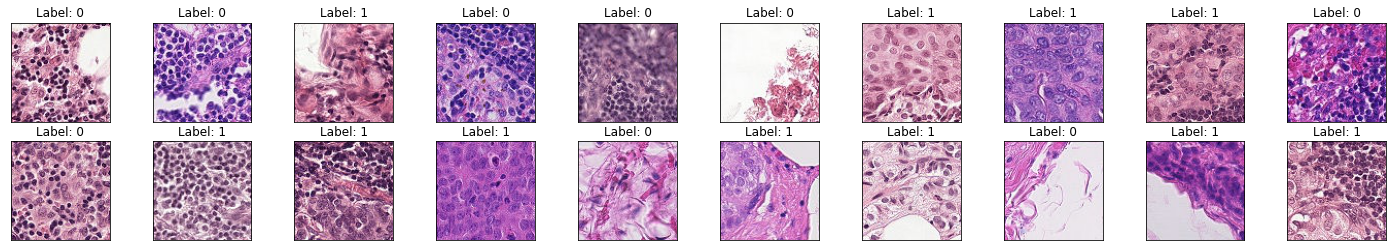

In [10]:
fig = plt.figure(figsize=(25, 4))
# display 20 images
train_imgs = os.listdir("../input/histopathologic-cancer-detection/train")
for idx, img in enumerate(np.random.choice(train_imgs, 20)):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    im = Image.open("../input/histopathologic-cancer-detection/train/" + img)
    plt.imshow(im)
    lab = cancer_labels.loc[cancer_labels['id'] == img.split('.')[0], 'label'].values[0]
    ax.set_title(f'Label: {lab}')

### Processing the dataset
The following information has been provided on the Kaggle and the Github where the dataset is hosted - "A positive label indicates that the center 32x32px region of a patch contains at least one pixel of tumor tissue. Tumor tissue in the outer region of the patch does not influence the label. This outer region is provided to enable the design of fully-convolutional models that do not use any zero-padding, to ensure consistent behavior when applied to a whole-slide image."

In [11]:
data_T_train = T.Compose([
    T.CenterCrop(32),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
data_T_test = T.Compose([
    T.CenterCrop(32),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

In [12]:
#indices for validation 
tr,val = train_test_split(cancer_labels.label,stratify=cancer_labels.label,test_size=0.1) 
# tr,val

I haven't found a way to load data in pytorch,when all train images are in one folder without subfolder. 
I have found an alternative-writing my own class for dataset creation. ~ANDREW LUKYANENKO ^-^ 
if you know one told me in the commens!

In [13]:
# Extracting the labels for the images that were selected in the downsampled data
# selected_image_labels = pd.DataFrame()
# id_list = []
# label_list = []

# for img in selected_image_labels:
#   label_tuple = cancer_labels.loc[cancer_labels['id'] == img.split('.')[0]]
#   id_list.append(label_tuple['id'].values[0])
#   label_list.append(label_tuple['label'].values[0])

In [14]:
# selected_image_labels['id'] = id_list
# selected_image_labels['label'] = label_list
# selected_image_labels.head()

In [15]:
# dictionary with labels and ids of train data
img_class_dict = {k:v for k,v in zip(cancer_labels.id,cancer_labels.label)}
# img_class_dict

In [16]:
class CancerDataset(Dataset):
    def __init__(self,datafolder,datatype='train',transform=T.Compose([T.CenterCrop(32),T.PILToTensor()]),labels_dict={}):
        self.datafolder = datafolder 
        self.datatype = datatype 
        self.image_files_list = [s for s in os.listdir(datafolder)]
        self.transform = transform 
        self.labels_dict = labels_dict 
        if self.datatype=='train':
            self.labels = [labels_dict[i.split('.')[0]] for i in self.image_files_list]
        else: 
            self.labels = [0 for _ in range(len(self.image_files_list))]
    def __len__(self):
        return len(self.image_files_list)
    def __getitem__(self,idx):
        img_name = os.path.join(self.datafolder,self.image_files_list[idx])
        image = Image.open(img_name)
        image = self.transform(image)
        img_name_short = self.image_files_list[idx].split('.')[0]
        
        if self.datatype=='train':
            label = self.labels_dict[img_name_short]
        else:
            label = 0 
        return image,label 
        

In [17]:
%%time 
#load train data 
dataset = CancerDataset(datafolder='../input/histopathologic-cancer-detection/train',datatype='train',transform=data_T_train,labels_dict=img_class_dict)

CPU times: user 231 ms, sys: 137 ms, total: 368 ms
Wall time: 370 ms


In [18]:
test_set = CancerDataset(datafolder='../input/histopathologic-cancer-detection/train',datatype='test',transform=data_T_test)


Pytorch lightning expects data to be in folders with the classes. We cannot use the DataLoader module directly when all train images are in one folder without subfolders. So, we will write our custom function to carry out the loading. 


In [19]:
train_sampler = SubsetRandomSampler(list(tr.index))
valid_sampler = SubsetRandomSampler(list(val.index))
batch_size = 256
num_workers=2
#prepare dataloaders (combine dataset and sampler )
train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, num_workers=num_workers)

In [20]:
class CNNImageClassifier(pl.LightningModule):
    def __init__(self,learning_rate=0.001):
        super().__init__()
        self.learning_rate = learning_rate 
        
        #input Size(256,3,32,32)
        self.conv_layer1 = nn.Conv2d(in_channels=3,out_channels=3,kernel_size=3,stride=1,padding=1)
        #output_shape  : (256,3,32,32)
        self.relu1 = nn.ReLU()
        #output_shape = (256,3,32,32)
        self.pool = nn.MaxPool2d(kernel_size=2)
        #output_shape = (256,3,16,16)
        self.conv_layer2 = nn.Conv2d(in_channels=3,out_channels=6,kernel_size=3,stride=1,padding=1)
        #output_shape : (256,3,16,16)
        self.relu2 = nn.ReLU()
        #output_shape : (256,6,16,16)
        self.fully_connected_1 =nn.Linear(in_features=16 * 16 * 6,out_features=1000)
        self.fully_connected_2 =nn.Linear(in_features=1000,out_features=500)
        self.fully_connected_3 =nn.Linear(in_features=500,out_features=250)
        self.fully_connected_4 =nn.Linear(in_features=250,out_features=120)
        self.fully_connected_5 =nn.Linear(in_features=120,out_features=60)
        self.fully_connected_6 =nn.Linear(in_features=60,out_features=2)
        self.loss = nn.CrossEntropyLoss()# since this is abinary classification,the output should be probability of 2 classes 
        self.save_hyperparameters()
    def forward(self,input):
        output=self.conv_layer1(input)
        output=self.relu1(output)
        output=self.pool(output)
        output=self.conv_layer2(output)
        output=self.relu2(output)
        output=output.view(-1, 6*16*16)
        output = self.fully_connected_1(output)
        output = self.fully_connected_2(output)
        output = self.fully_connected_3(output)
        output = self.fully_connected_4(output)
        output = self.fully_connected_5(output)
        output = self.fully_connected_6(output)
        return output
    def training_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs) 
        train_accuracy = accuracy(outputs, targets)
        loss = self.loss(outputs, targets)
        self.log('train_accuracy', train_accuracy, prog_bar=True)
        self.log('train_loss', loss)
        return {"loss":loss, "train_accuracy":train_accuracy}

    def test_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self.forward(inputs)
        test_accuracy = accuracy(outputs, targets)
        loss = self.loss(outputs, targets)
        self.log('test_accuracy', test_accuracy)
        #we are logging accuracy and loss for our train dataset,These logged values can be later be used for plotting our chars 
        #or for further investigation and will help us to tune the model. 
        return {"test_loss":loss, "test_accuracy":test_accuracy}

    def configure_optimizers(self):
        params = self.parameters()
        optimizer = optim.AdamW(params=params, lr = self.learning_rate)
        return optimizer
    # Calculate accuracy for each batch at a time
    def binary_accuracy(self, outputs, targets):
        _, outputs = torch.max(outputs,1)
        correct_results_sum = (outputs == targets).sum().float()
        acc = correct_results_sum/targets.shape[0]
        return acc

    def predict_step(self, batch, batch_idx ):
        return self(batch)        

In [ ]:
ckpt_dir = "./"
ckpt_callback = pl.callbacks.ModelCheckpoint(every_n_epochs=10)

model = CNNImageClassifier()
trainer = pl.Trainer(
    default_root_dir=ckpt_dir,
                     gpus=2,
                    strategy='ddp_notebook',
                        callbacks=[ckpt_callback],
                        log_every_n_steps=25,
                        max_epochs=200)
trainer.fit(model, train_dataloaders=train_loader)

In [ ]:
trainer.test(test_dataloaders=test_loader)

In [ ]:
model.eval()
preds = []
for batch_i, (data, target) in enumerate(test_dataloader):
    data, target = data.cuda(), target.cuda()
    output = model.cuda()(data)

    pr = output[:,1].detach().cpu().numpy()
    for i in pr:
        preds.append(i)

In [ ]:
test_preds = pd.DataFrame({'imgs': test_set.list_image_files, 'labels':test_set.labels,  'preds': preds})


In [ ]:
test_preds['imgs'] = test_preds['imgs'].apply(lambda x: x.split('.')[0])


In [ ]:
test_preds.head()

In [ ]:
test_preds['predictions'] = 1
test_preds.loc[test_preds['preds'] < 0, 'predictions'] = 0
test_preds.shape

In [ ]:
test_preds.head()

In [ ]:
len(np.where(test_preds['labels'] == test_preds['predictions'])[0])/test_preds.shape[0]

# using pretrained model 
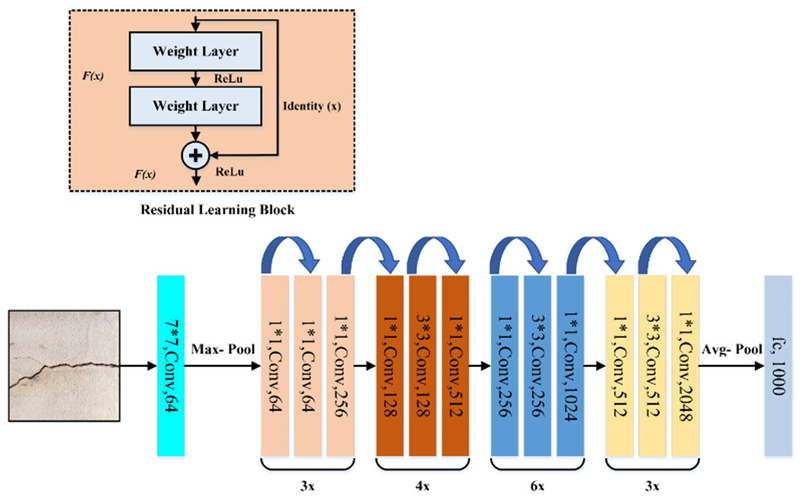

In the ResNet-50 model architecture, there are 48 convolution layers along with 1 AvgPool
layer and 1 MaxPool layer.
The ResNet-50 model on ImageNet has been trained for several weeks in its compute
process. Again, a fantastic benefit of transfer learning, as mentioned in the introduction,
is that we don't need to train the model from scratch; rather, we can simply use the
weights of the model and bootstrap the whole process.

In [22]:
!pip install albumentations > /dev/null

In [23]:
import albumentations

In [24]:
albumentations.__version__

'1.3.0'

In [27]:
import pretrainedmodels

In [28]:
class CancerDataset(Dataset):
    def __init__(self, datafolder, datatype='train', transform = T.Compose([T.CenterCrop(32),T.ToTensor()]), labels_dict={}):
        self.datafolder = datafolder
        self.datatype = datatype
        self.image_files_list = [s for s in os.listdir(datafolder)]
        self.transform = transform
        self.labels_dict = labels_dict
        if self.datatype == 'train':
            self.labels = [labels_dict[i.split('.')[0]] for i in self.image_files_list]
        else:
            self.labels = [0 for _ in range(len(self.image_files_list))]

    def __len__(self):
        return len(self.image_files_list)

    def __getitem__(self, idx):
        img_name = os.path.join(self.datafolder, self.image_files_list[idx])
        img = cv2.imread(img_name)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image = self.transform(image=img)
        image = image['image']

        img_name_short = self.image_files_list[idx].split('.')[0]

        if self.datatype == 'train':
            label = self.labels_dict[img_name_short]
        else:
            label = 0
        return image, label

In [31]:
data_transforms = albumentations.Compose([
    albumentations.Resize(224, 224),
    albumentations.HorizontalFlip(),
    albumentations.RandomBrightness(),
    albumentations.ShiftScaleRotate(rotate_limit=15, scale_limit=0.10),
    albumentations.JpegCompression(80),
    albumentations.HueSaturationValue(),
    albumentations.Normalize(),
    T.ToTensor()
    ])
data_transforms_test = albumentations.Compose([
    albumentations.Resize(224, 224),
    albumentations.Normalize(),
    T.ToTensor()
    ])

dataset = CancerDataset(datafolder='../input/histopathologic-cancer-detection/train', datatype='train', transform=data_transforms, labels_dict=img_class_dict)
test_set = CancerDataset(datafolder='../input/histopathologic-cancer-detection/test', datatype='test', transform=data_transforms_test)
train_sampler = SubsetRandomSampler(list(tr.index))
valid_sampler = SubsetRandomSampler(list(val.index))
batch_size = 32
num_workers = 0
# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, num_workers=num_workers)

# Building the model 

In [33]:
class CancerImageClassifier(pl.LightningModule):
    def __init__(self,learning_rate=1e-3):
        super().add_module__init__()
        
        self.learning_rate = learning_rate 
        self.loss = nn.CrossEntropyLoss()
        # freeze the wieghts for the existing layers to avoid backpropagtation 
        self.pretrain_model = resnet50(pretrained=True)
        for param in self.pretrain_model.parameters(): 
            param.requires_grad = False 
        # let's change the final layer of ResNet50 model so that we can classify the two categories 
        self.pretrain_model.fc = nn.Linear(2048,2)
    def forward(self,input):
        output = self.pretrain_model(input)
        return output 
    def configure_optimizers(self):
        params = self.parameters() 
        optimizer = optim.AdamW(params=params,lr=self.learning_rate)
        return optimizer
    def training_step(self,batch,batch_idx):
        inputs,targets = batch 
        outputs = self(inputs)
        preds = torch.argmax(outputs,dim=1)#returns the indices of the maximum value of all elements
        #in the input tensor 
        train_accuracy = accuracy(preds,targets)
        loss = self.loss(outputs,targets)
        self.log('train_accuracy',train_accuracy,prog_bar=True)
        self.log('train_loss',loss)
        return {'loss':loss,'train_accuracy':train_accuracy}
    def test_step(self,batch,batch_idx):
        inputs,targets = batch 
        outputs = self.forward(inputs)
        preds = torch.argmax(outputs,dim=1)
        test_accuracy = accuracy(preds,targets)
        loss = self.loss(outputs,targets)
        return {"test_loss":loss,"test_accuracy":test_accuracy}
    def test_epoch_end(self,outputs):
        test_outs = []
        for test_out in outputs: 
            out = test_out['test_accuracy']
            test_outs.append(out)
        total_test_accuracy = torch.stack(test_outs).mean()
        self.log('total_test_accuracy',total_test_accuracy,on_step=False,on_epoch=True)
        return total_test_accuracy 

In [ ]:

ckpt_dir = "./"
ckpt_callback = pl.callbacks.ModelCheckpoint(every_n_epochs=10)

model = CancerImageClassifier()
trainer = pl.Trainer(
    default_root_dir=ckpt_dir,
                     gpus=2,
                    strategy='ddp_notebook',
                        callbacks=[ckpt_callback],
                        log_every_n_steps=25,
                        max_epochs=10)
trainer.fit(model, train_dataloaders=train_loader)

In [ ]:
trainer.test(test_dataloaders=test_loader)